In [59]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [60]:
# defining functions we will need to use later (claude assisted)

# defining the uniform kernel
def uniform_kernel(u):
    return 0.5 * (np.abs(u) <= 1)

# defining the gaussian kernel
from scipy.stats import norm
def gaussian_kernel(u):
    return norm.pdf(u)

# defining the kde function that requires the specified kernel as defined above
def kde(x, data, h, kernel):
    x = np.atleast_1d(x).astype(float)
    data = np.asarray(data, dtype=float)
    u = (x[:, None] - data[None, :]) / h
    return kernel(u).sum(axis=1) / (len(data) * h)

# Problem 1

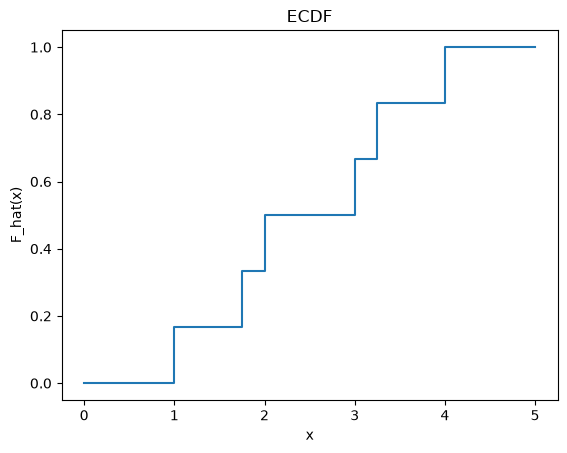

In [61]:
# a)
# defining what was given
x1 = np.array([1, 1.75, 2, 3, 3.25, 4])

# computing ecdf
xs = np.sort(x1) # first has to be sorted
ecdf = np.arange(1, 6 + 1) / 6

# plotting (found plt.step from claude)
plt.step(np.r_[0, xs, 5], np.r_[0, ecdf, 1], where='post')
plt.xlabel('x')
plt.ylabel('F_hat(x)')
plt.title('ECDF')
plt.show()

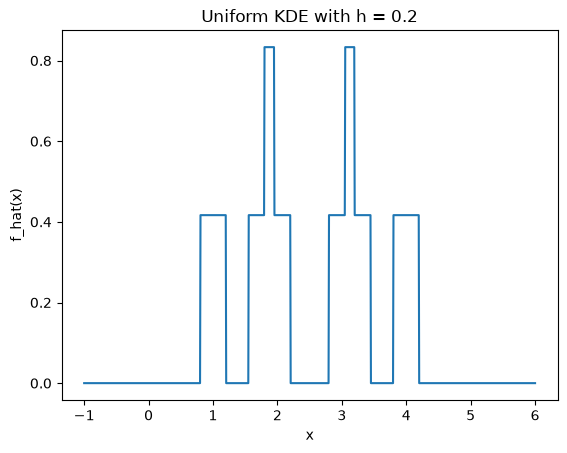

In [62]:
# b)
# using a grid plot to show the uniform kernel applied
# setting up grid
grid = np.linspace(-1, 6, 1001)
# using built-in kde function found from claude
plt.plot(grid, kde(grid, x1, 0.2, uniform_kernel))
plt.xlabel('x')
plt.ylabel('f_hat(x)')
plt.title('Uniform KDE with h = 0.2')
plt.show()

In [63]:
# c) 
n = len(x1)
sd = np.std(x1) # using built-in numpy function
h_silverman = 1.84 * sd * n ** (-0.2)
print(sd)
print(h_silverman)

1.0103629710818451
1.2991670409500977


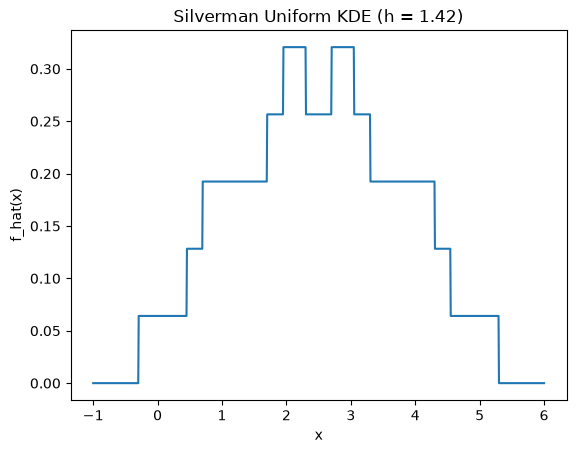

In [64]:
# d)
plt.plot(grid, kde(grid, x1, h_silverman, uniform_kernel))
plt.xlabel('x')
plt.ylabel('f_hat(x)')
plt.title(f'Silverman Uniform KDE (h = 1.42)')
plt.show()

In [65]:
# e)
# written on paper

# Problem 2

In [66]:
# a)
x2 = np.array([-1, -0.5, 0, 0.5, 1])
h = 0.6

# calculated by hand on paper submitted

In [67]:
# b) 

prob_from_norm = 2 * norm.cdf(0.6) - 1
print(prob_from_norm)
part2b = prob_from_norm * (1/ (2* 0.6))
print(part2b)

0.4514937644998529
0.37624480374987745


In [68]:
# c)
# answer on paper

In [69]:
# d) 
prob_from_norm_d= 2 * norm.cdf(0.1) - 1
print(prob_from_norm_d)
part2d = prob_from_norm_d * (1/ (2* 0.1))
print(part2d)

0.07965567455405798
0.3982783727702899


In [70]:
# e)
# answer written on paper

In [71]:
# f) 
# answer written on paper

In [72]:
# g) 
# answer written on paper

# Problem 3

In [73]:
# a)

# defining the given data
x3 = np.array([5, 7, 7, 8, 10])
h = 1.5
x_pts_to_run = np.array([6.0, 6.5, 7.0, 8.0, 8.5])

# using the kde function and uniform_kernel function from above to pull the f hat values
uniform_kde_values = kde(x_pts_to_run, x3, h, uniform_kernel)

# printing the results
print(f"f_hat(6.0) =", uniform_kde_values[0])
print(f"f_hat(6.5) =", uniform_kde_values[1])
print(f"f_hat(7.0) =", uniform_kde_values[2])
print(f"f_hat(8.0) = ", uniform_kde_values[3])
print(f"f_hat(8.5) = ", uniform_kde_values[4])

f_hat(6.0) = 0.2
f_hat(6.5) = 0.26666666666666666
f_hat(7.0) = 0.2
f_hat(8.0) =  0.2
f_hat(8.5) =  0.26666666666666666


ANSWER:

So the values for f_hat at each of the values can be seen in the cell output above.

In [74]:
# b)

# using the kde function and gaussian_kernel function from above
gaussian_kde_values = kde(x_pts_to_run, x3, h, gaussian_kernel)

# printing the results
print(f"f_hat(6.0) =", gaussian_kde_values[0])
print(f"f_hat(6.5) =", gaussian_kde_values[1])
print(f"f_hat(7.0) =", gaussian_kde_values[2])
print(f"f_hat(8.0) =", gaussian_kde_values[3])
print(f"f_hat(8.5) =", gaussian_kde_values[4])

f_hat(6.0) = 0.15116667696891303
f_hat(6.5) = 0.16865730580239766
f_hat(7.0) = 0.17804448100191994
f_hat(8.0) = 0.16744524435137584
f_hat(8.5) = 0.1506023053792177


In [75]:
#c)

ANSWER:

Yes, the part a values jump from 0.2 at most x values to 0.266 at x=6.5 and 8.5 while the values for part b do not display these big jumps. Going from an f_hat value of 0.2 to 0.266 while x only increases by 0.5 at these specified points highlights how the uniform KDE is part a is jagged. This makes sense if we consider how the kernels function. The uniform kernel from part a gives points a value of either 0.5 or 0  depending on how far they are away from the data point of interest while the gaussian kernel from part b lets values takes on more smoothed values depending on how far the point is from the data point of interest. Since the uniform kernel has these sharp jumps/edges while the gaussian kernel does not, this explains the differences we see in part a from part b.

In [76]:
# d)

ANSWER:

Each of the kernels has its own properties that may come in handy when applying them to different practices. The uniform kernel has sharp jumps/cutoffs that may be helpful for something involving signaling that requires quick spikes. It may also be more helpful if we want to apply this kernel by hand since it is much easier to calculate than the gaussian. The gaussian kernel seems to be applicable to more scenarios since it has those smoother estimates. Here we can see that it can be preferred when looking at the distribution of data, so for data analytic purposes. Either way, the properties of both kernels can be exploited to be helpful in different scenarios, but for the purpose of our class the gaussian kernel would seem stronger.

# Problem 4

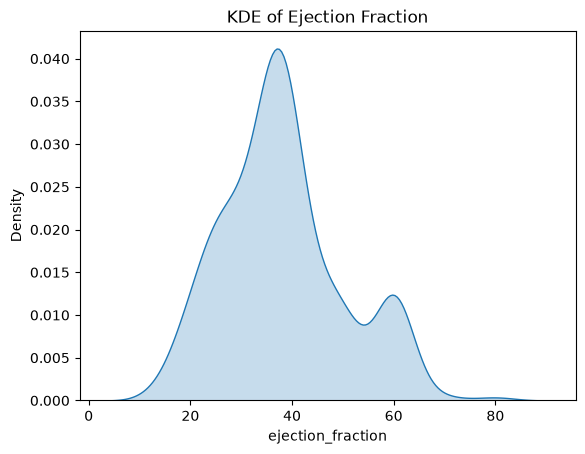

In [77]:
# a)
import seaborn as sns

df = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')
df['ejection_fraction'].describe()

# a)
sns.kdeplot(data = df, x = 'ejection_fraction', fill = True).set(title = 'KDE of Ejection Fraction')
plt.show()

ANSWER:

Using the kde function from seaborn (the one we used in class), we can see the KDE of ejection fraction. The data appears to be bimodal, with the largest gathering around an ejection fraction of 39 which hits a dnesity of about 0.04 and a smaller clumping around an ejection fraction of 60 which hits a dnesity of about 0.0123. The general shape as a right-skewed, and the minimum is around 10% with a maximum of about 85%.

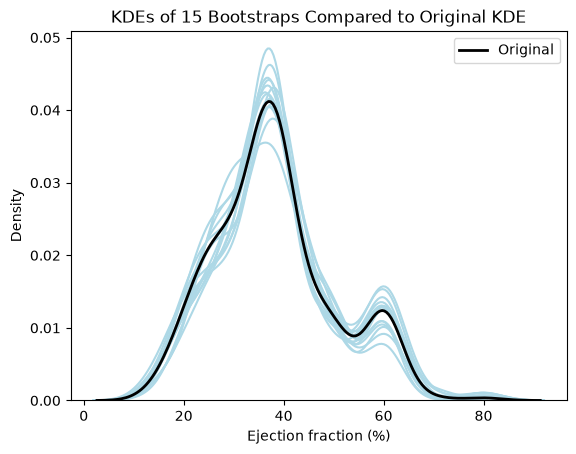

In [83]:
# b)

# used claude to help with subplot to overlap them
fig, ax = plt.subplots()

# looping over 15 samples like specified
for i in range(15):
    # line from the problem with how to sample
    one_bootstrap = df.sample(frac=1.0, replace=True) 
    # applying same seaborn kde function to plot it
    sns.kdeplot(one_bootstrap['ejection_fraction'], ax=ax, color = 'lightblue')

# plotting the original KDE to see how the bootstrapping samples compare
sns.kdeplot(df['ejection_fraction'], ax=ax, color = 'black', linewidth = 2, label = "Original")
ax.set_xlabel('Ejection fraction (%)')
ax.set_title('KDEs of 15 Bootstraps Compared to Original KDE')
ax.legend()
plt.show()

ANSWER:

From this plot we can see that the bootstrapped samples generally capture the shape of the original KDE. They find the same peaks and approximate densities, but there is notable variation.

In [79]:
# c) 

ANSWER:

Comparing the original KDE to the bootstrapped KDE's, we can find where the original plot is reliable by looking at the variation between the KDE's. For ejection fractions with higher densities ( around 20-45), the overlap is pretty consistent. This is too be expected because this is where a large portion of our data lies, so we expect all of the boostraps to have a decent number of of observations there. However, as we move away from this central "clump" of data that captures a large portion of our sample, the KDE's overlap less. The most variation can be see around the second smaller density spike around 60% ejection fraction, with continued variation around the tails. Since there are much fewer patients in these region of the data, each bootstrap will contain a varied proportion of these points in thier sample, and will the proportion jumping a lot because we are dealing with few observations, the height of the densities in these regions will vary. For example, one bootstrap may only have 1/20 of its data points in the 60% region but another could have 3/20 of its data points in this region, and while 1 and 3 are close, this would give a drastically different measure of density between these two samples. Putting this together, the KDE is most reliable where data is dense and lease reliable/noisy where data is sparse.